# Health-Based Clustering of Turkish Provinces Using Data Mining Techniques

**Author:** Daniyal Hemmati  
**Affiliation:** Department of Management Information Systems, Istanbul Medipol University  
**Project Type:** Independent Data Analytics Portfolio Project  
**Date:** June 2026



## Introduction

This project investigates similarities among the 81 provinces of Türkiye using a focused set of health-related indicators obtained from the TÜİK Provincial Well-Being Index dataset.

The project was developed as a health-focused partial replication and methodological extension of Doğuç, Şahinbaş, and Silahtaroğlu (2023). It does not attempt to reproduce the complete dataset, algorithms, cluster-selection procedure, or results of the original study.

Instead, it examines whether meaningful provincial patterns remain visible when a smaller set of health-related variables is analyzed using K-Means clustering, Principal Component Analysis (PCA), and Fuzzy C-Means clustering.


## About the Reference Study

Doğuç et al. (2023) investigated similarities and differences among Turkish provinces using 142 demographic variables collected through TÜİK. The variables were drawn from 23 source categories and analyzed through an overall clustering model and several thematic perspectives, including education, population, health, security, purchasing power, satisfaction, and cultural opportunities.

The authors applied an enhanced Fuzzy C-Means approach and evaluated different cluster numbers using cluster-validity measures such as the Xie–Beni Index, Partition Entropy, and Partition Coefficient. Their findings highlighted differences between eastern and western provinces, the distinctive characteristics of major metropolitan provinces, and the possible influence of large cities on neighboring provinces.

## Positioning of This Project

The present project has a narrower scope than the reference study. Whereas the original study analyzed 142 variables across multiple demographic domains, this project uses five health-related indicators:

1.Infant mortality rate
2.Life expectancy at birth
3.Applications per doctor
4.Health satisfaction rate
5.Public-health-service satisfaction rate

In the reference article, infant mortality and life expectancy are listed under the Demography category, while the remaining three variables are listed under Health. Therefore, this project uses the broader and more accurate term health-related indicators rather than claiming to reproduce the article’s exact health-variable subset.

The analysis should consequently be understood as an exploratory partial replication that focuses on one substantive area while adding alternative methods and visual diagnostics.

## Research Question

 This exploratory project addresses the following questions:

 1. What provincial health-related profiles emerge when K-Means clustering with three clusters is applied to the five standardized indicators?
 2. How do the resulting clusters differ in infant mortality, life expectancy, applications per doctor, health satisfaction, and satisfaction with  public health services?
 3. How are the K-Means clusters represented in the first two principal components, and which provinces appear as distinctive observations within the PCA space?
 4. What does Fuzzy C-Means reveal about overlapping cluster characteristics and provinces with uncertain membership?
 5. How strongly does the eastern and southeastern grouping identified in this project overlap with the health-services grouping reported by Doğuç et al. (2023)?

## Import Libraries

The required Python libraries are imported in this section. These libraries are used for data cleaning, numerical processing, clustering, dimensionality reduction, and visualization.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import skfuzzy as fuzz

In [16]:
file_path = r"C:\Users\sejron.com\Downloads\İllerde Yaşam Endeksi Gösterge Değerleri.xls"

df = pd.read_excel(file_path, header=4)

df = df.dropna(axis=1, how="all")
df = df.dropna(axis=0, how="all")

print("Rows, Columns:", df.shape)
df.head()

Rows, Columns: (84, 42)


,Unnamed: 0,Konut\nHousing,Unnamed: 3,Unnamed: 4,Çalışma hayatı\nWork life,Unnamed: 7,Unnamed: 8,Unnamed: 9,Gelir ve servet\nIncome and wealth,Unnamed: 12,...,Unnamed: 40,Altyapı hizmetlerine erişim\nAccess to infrastructure services,Unnamed: 43,Unnamed: 44,Unnamed: 45,Sosyal yaşam\nSocial life,Unnamed: 48,Unnamed: 49,Unnamed: 50,Yaşam memnuniyeti\nLife satisfaction
0,İl\nProvince,Fert başına düşen oda sayısı \nNumber of roo...,Konutun içinde tuvalet mevcudiyeti oranı\n(%)\...,Konutun kalitesinde problem yaşayanların oranı...,İstihdam oranı \n(%) Employment rate \n(%),İşsizlik oranı \n(%) Unemployment rate \n(%),Ortalama günlük kazanç \n(TL) Average daily ea...,İşinden memnuniyet oranı \n(%) \nJob satisfact...,Kişi başına düşen tasarruf mevduatı\n(TL) \nS...,Orta ve üstü gelir grubundaki hanelerin oranı\...,...,Sendika/dernek faaliyetleri ile ilgili olanlar...,İnternet abone sayısı (yüz kişide)\nNumber of ...,Kanalizasyon ve şebeke suyuna erişim oranı\n(%...,Havalimanına erişim oranı\nAccess rate to airport,Belediyenin toplu taşıma hizmetlerinden memnun...,Sinema ve tiyatro seyirci sayısı (yüz kişide) ...,Bin kişi başına düşen alışveriş merkezi alanı\...,Sosyal ilişkilerinden memnuniyet oranı \n(%) \...,Sosyal hayatından memnuniyet oranı \n(%) \nSat...,Mutluluk düzeyi \n(%) \nLevel of happiness \n(%)
2,Adana,1.22,86.34,22.73,43.3,13.2,59.064891,73.32,5427.724944,34.06,...,7.6,9.737647,91.500003,7449.761905,56.34,73.090444,82.44524,81.9,46.74,53
3,Adıyaman,0.93,77.07,41.12,39.2,9.1,53.242814,64.26,1542.666455,16.27,...,6.98,3.714905,67.715925,74.326923,36.72,2.903811,0,81.82,56.88,65.01
4,Afyonkarahisar,1.36,90.2,12.9475,51.1,5.6,53.911573,85.34,4062.055209,29.73,...,5.71,7.035255,71.867758,11.96944,74.24,34.917628,119.90866,94.04,70.29,76.43
5,Ağrı,0.84,64.06,40.475,53.2,6.8,56.108035,63.97,842.04683,22.56,...,6.36,2.163495,50.363737,167.02381,48.54,6.321949,0,90.04,46.16,60.09


## Data Cleaning and Health Indicator Extraction

The original TÜİK dataset contains multiple demographic categories and formatting artifacts inherited from the Excel source. Therefore, the data was cleaned before analysis.

The cleaning process involved:

- Removing unnecessary rows and columns
- Renaming variables with clear English names
- Selecting only health-related indicators
- Converting numerical columns to appropriate data types
- Checking for missing values

The final dataset contains five health indicators for all 81 Turkish provinces.    

### Cleaning Results

After cleaning:

- 81 provinces remained in the dataset
- 5 health indicators were selected
- All numerical variables were converted to numeric format
- The dataset became suitable for clustering analysis

The resulting dataset contains one row per province and one column for each selected health indicator.

In [17]:
health_df = df.iloc[:, [0, 11, 12, 13, 14, 15]].copy()

health_df.columns = [
    "Province",
    "Infant_Mortality",
    "Life_Expectancy",
    "Applications_Per_Doctor",
    "Health_Satisfaction",
    "Public_Health_Satisfaction"
]

health_df = health_df.iloc[1:-2].reset_index(drop=True)

for col in health_df.columns[1:]:
    health_df[col] = pd.to_numeric(health_df[col], errors="coerce")

print("Rows, Columns:", health_df.shape)
health_df.head(10)


Rows, Columns: (81, 6)


,Province,Infant_Mortality,Life_Expectancy,Applications_Per_Doctor,Health_Satisfaction,Public_Health_Satisfaction
0,Adana,13.181440,77.393347,5323.229963,68.47,72.47
1,Adıyaman,12.061484,79.548204,7437.146774,69.13,74.62
2,Afyonkarahisar,9.572374,76.992118,5727.391389,80.07,87.33
3,Ağrı,14.432990,75.628295,6719.994012,66.20,63.31
4,Amasya,15.384615,77.767141,8067.414698,74.16,86.51
5,Ankara,6.958851,79.373517,2763.261636,71.76,68.11
6,Antalya,8.913018,79.220753,4392.388216,68.45,68.74
7,Artvin,7.759457,79.280264,6300.734300,80.05,80.13
8,Aydın,9.169563,78.702168,4953.537811,73.38,78.03
9,Balıkesir,7.106523,77.608151,6702.474425,75.44,83.01


## Dataset Overview

After cleaning and extracting the health-related indicators, the final dataset contains information for all 81 Turkish provinces.

The selected variables are:

- Infant Mortality Rate
- Life Expectancy at Birth
- Applications Per Doctor
- Health Satisfaction Rate
- Public Health Service Satisfaction Rate

These indicators capture both objective healthcare outcomes and subjective satisfaction measures.

In [21]:
health_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 6 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Province                    81 non-null     str    
 1   Infant_Mortality            81 non-null     float64
 2   Life_Expectancy             81 non-null     float64
 3   Applications_Per_Doctor     81 non-null     float64
 4   Health_Satisfaction         81 non-null     float64
 5   Public_Health_Satisfaction  81 non-null     float64
dtypes: float64(5), str(1)
memory usage: 3.9 KB


In [20]:
health_df.describe()

,Infant_Mortality,Life_Expectancy,Applications_Per_Doctor,Health_Satisfaction,Public_Health_Satisfaction
count,81.000000,81.000000,81.000000,81.000000,81.000000
mean,10.994693,78.135209,5834.365148,71.996543,77.467654
std,3.399020,1.037074,1245.160441,4.448398,7.305076
min,5.273834,74.954996,2763.261636,59.150000,54.550000
25%,8.567145,77.542133,4955.489660,69.320000,72.600000
50%,10.314424,77.995544,5786.546358,72.020000,78.850000
75%,12.868633,78.704372,6774.477477,74.290000,82.590000
max,25.727827,80.504309,8067.414698,80.760000,89.130000


## Data Standardization

The selected health indicators are measured on different scales. For example, life expectancy is measured in years, while applications per doctor are measured in thousands.

If clustering is performed directly on the raw data, variables with larger numerical values may dominate the analysis. Therefore, z-score standardization is applied using StandardScaler.

After standardization, each variable has:

- Mean approximately equal to 0
- Standard deviation approximately equal to 1

This ensures that all variables contribute equally to the clustering process.

In [22]:
features = health_df.drop("Province", axis=1)

scaler = StandardScaler()

health_scaled = scaler.fit_transform(features)

In [23]:
scaled_df = pd.DataFrame( 

    
    health_scaled,
    columns=features.columns
)

scaled_df.insert(
    0,
    "Province",
    health_df["Province"]
)

scaled_df.head()

,Province,Infant_Mortality,Life_Expectancy,Applications_Per_Doctor,Health_Satisfaction,Public_Health_Satisfaction
0,Adana,0.647355,-0.719799,-0.413055,-0.797707,-0.688397
1,Adıyaman,0.315808,1.370971,1.295229,-0.648414,-0.392247
2,Afyonkarahisar,-0.421057,-1.109095,-0.086447,1.826222,1.358479
3,Ağrı,1.017858,-2.432356,0.715688,-1.311182,-1.950132
4,Amasya,1.299573,-0.357121,1.804557,0.489375,1.245529


In [24]:
scaled_df.describe()

,Infant_Mortality,Life_Expectancy,Applications_Per_Doctor,Health_Satisfaction,Public_Health_Satisfaction
count,8.100000e+01,8.100000e+01,8.100000e+01,8.100000e+01,8.100000e+01
mean,3.735010e-17,7.304171e-15,-8.772133e-17,-1.582068e-15,-1.214392e-15
std,1.006231e+00,1.006231e+00,1.006231e+00,1.006231e+00,1.006231e+00
min,-1.693577e+00,-3.085630e+00,-2.481799e+00,-2.905897e+00,-3.156770e+00
25%,-7.186403e-01,-5.754375e-01,-7.102309e-01,-6.054359e-01,-6.704904e-01
50%,-2.013839e-01,-1.355113e-01,-3.864300e-02,5.305942e-03,1.904099e-01
75%,5.547526e-01,5.522355e-01,7.597172e-01,5.187815e-01,7.055726e-01
max,4.361530e+00,2.298640e+00,1.804557e+00,1.982300e+00,1.606419e+00


### Interpretation

The standardized dataset has a mean close to zero and a standard deviation close to one for all variables. This confirms that the scaling process was successful.

As a result, no single variable dominates the clustering process due to differences in measurement units or magnitude.

## K-Means Clustering

K-Means clustering is used to group provinces with similar health characteristics.

The algorithm partitions the provinces into clusters by minimizing the distance between observations and their assigned cluster centers.

In this project, three clusters are used to identify distinct health-service profiles among Turkish provinces.

In [25]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(health_scaled)

scaled_df["Cluster"] = clusters
health_df["Cluster"] = clusters

In [26]:
health_df["Cluster"].value_counts().sort_index()

Cluster
0    29
1    23
2    29
Name: count, dtype: int64

### Cluster Distribution

The clustering algorithm assigned each of the 81 provinces to one of three health-related clusters.

The cluster sizes provide an overview of how provinces are distributed among the identified health-service profiles.

In [29]:
cluster_scaled_summary = scaled_df.groupby("Cluster").mean(
    numeric_only=True
)

cluster_scaled_summary

,Infant_Mortality,Life_Expectancy,Applications_Per_Doctor,Health_Satisfaction,Public_Health_Satisfaction
Cluster,,,,,
0,-0.472665,0.081550,0.754608,0.667606,0.717305
1,1.059478,-0.343836,0.330616,-0.986338,-0.932803
2,-0.367611,0.191147,-1.016821,0.114662,0.022505


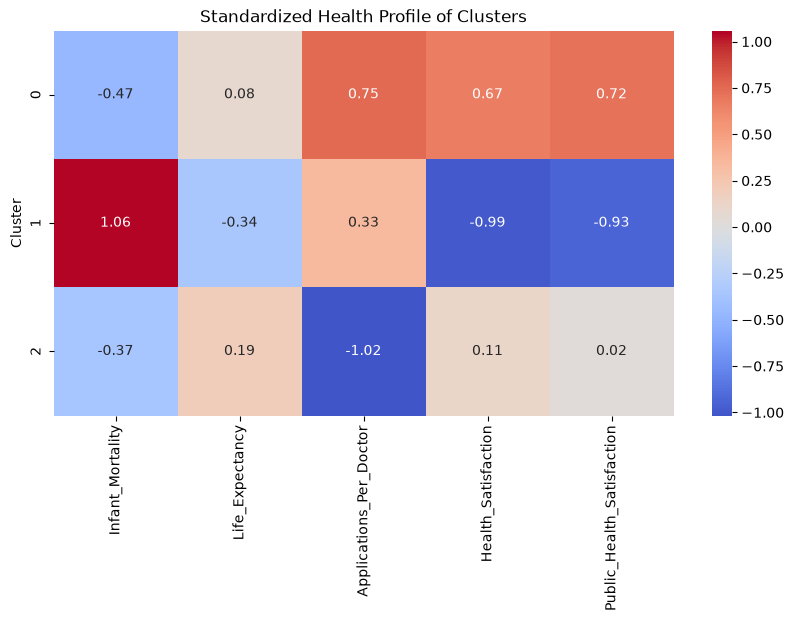

In [30]:
plt.figure(figsize=(10,5))

sns.heatmap(
    cluster_scaled_summary,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Standardized Health Profile of Clusters")
plt.show()

### Interpretation

The standardized heatmap reveals clear differences among the three clusters. Cluster 0 generally exhibits below-average health outcomes, while Cluster 1 shows stronger performance in satisfaction-related indicators. Cluster 2 is characterized by higher life expectancy and lower healthcare workload per physician. Overall, the results suggest that Turkish provinces can be grouped into distinct health-service profiles based on the selected indicators.

## Principal Component Analysis (PCA)

Principal Component Analysis (PCA) is applied to reduce the dimensionality of the dataset while preserving as much information as possible. By transforming the five health indicators into two principal components, the cluster structure can be visualized in a two-dimensional space.

In [31]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_result = pca.fit_transform(health_scaled)

pca_df = pd.DataFrame(
    pca_result,
    columns=["PC1", "PC2"]
)

pca_df["Province"] = health_df["Province"].values
pca_df["Cluster"] = scaled_df["Cluster"].values

In [32]:
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal Variance Explained:")
print(sum(pca.explained_variance_ratio_))

Explained Variance Ratio:
[0.36577592 0.25575409]

Total Variance Explained:
0.6215300102276113


In [40]:
important_provinces = [
    "İstanbul",
    "Ankara",
    "İzmir",
    "Antalya",
    "Adana",
    "Şanlıurfa",
    "Van",
    "Kocaeli",
    "Eskişehir",
    "Samsun"
]

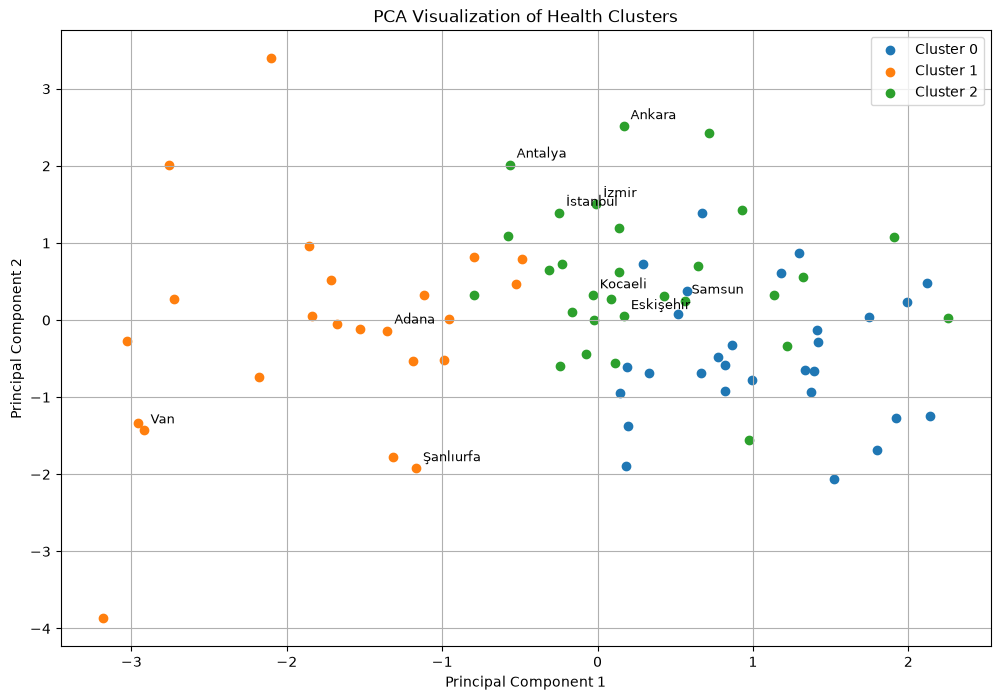

In [41]:
plt.figure(figsize=(12,8))

for cluster in sorted(pca_df["Cluster"].unique()):
    subset = pca_df[pca_df["Cluster"] == cluster]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=f"Cluster {cluster}"
    )

for _, row in pca_df.iterrows():
    if row["Province"] in important_provinces:
        plt.annotate(
            row["Province"],
            (row["PC1"], row["PC2"]),
            fontsize=9,
            xytext=(5,5),
            textcoords="offset points"
        )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of Health Clusters")
plt.legend()
plt.grid(True)

plt.show()

In [42]:
# Identify the most unusual province in each cluster based on PCA distance from the cluster center

cluster_centers_pca = pca_df.groupby("Cluster")[["PC1", "PC2"]].mean()

unusual_provinces = []

for cluster in sorted(pca_df["Cluster"].unique()):
    subset = pca_df[pca_df["Cluster"] == cluster].copy()
    center = cluster_centers_pca.loc[cluster]

    subset["Distance_From_Center"] = np.sqrt(
        (subset["PC1"] - center["PC1"])**2 +
        (subset["PC2"] - center["PC2"])**2
    )

    most_unusual = subset.sort_values(
        "Distance_From_Center",
        ascending=False
    ).iloc[0]

    unusual_provinces.append({
        "Cluster": cluster,
        "Province": most_unusual["Province"],
        "Distance_From_Center": most_unusual["Distance_From_Center"]
    })

unusual_df = pd.DataFrame(unusual_provinces)

unusual_df

,Cluster,Province,Distance_From_Center
0,0,Ordu,1.890659
1,1,Kilis,4.000980
2,2,Kırıkkale,2.213215


### Interpretation

The first two principal components explain approximately 62% of the total variation in the dataset, allowing the five health indicators to be visualized in a two-dimensional space. The PCA plot shows that the clusters occupy different regions, supporting the validity of the clustering results.

Several major provinces were labeled to provide geographic context and improve interpretability. In addition, the most unusual province within each cluster was identified based on its distance from the cluster center in the PCA space. These provinces represent distinctive health profiles compared with other provinces in the same cluster and may warrant further investigation.

In [ ]:
## Fuzzy C-Means Clustering

Unlike K-Means clustering, which assigns each province to exactly one cluster, Fuzzy C-Means allows provinces to belong to multiple clusters with different membership degrees.

This approach is useful when cluster boundaries are not completely distinct and provides a more flexible representation of provincial similarities.

In [45]:
import skfuzzy as fuzz
import numpy as np

data_for_fcm = health_scaled.T

cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
    data_for_fcm,
    c=3,
    m=2,
    error=0.005,
    maxiter=1000,
    seed=42
)

fuzzy_labels = np.argmax(u, axis=0)

print("Fuzzy Partition Coefficient:", fpc)
print(fuzzy_labels[:10])

Fuzzy Partition Coefficient: 0.44514046342380875
[2 2 0 2 0 1 1 0 1 0]


### Fuzzy Partition Coefficient

The Fuzzy Partition Coefficient (FPC) obtained from the model is approximately 0.445.

An FPC value closer to 1 indicates highly distinct clusters, whereas values closer to 0 indicate substantial overlap between clusters. The obtained result suggests moderate cluster separation, implying that while meaningful provincial groups exist, some provinces share characteristics with multiple clusters.

This finding is consistent with the complexity of health-related indicators, where provincial profiles may not always belong exclusively to a single category.

### Membership Degrees

The table below presents the cluster membership values obtained from the Fuzzy C-Means algorithm. Unlike K-Means, which assigns each province to a single cluster, Fuzzy C-Means estimates the degree to which a province belongs to each cluster.

Higher membership values indicate a stronger association with a particular cluster, while more balanced values suggest that a province shares characteristics with multiple health profiles.

In [48]:
fuzzy_df = pd.DataFrame({
    "Province": health_df["Province"],
    "FCM_Cluster": fuzzy_labels,
    "Membership_Cluster_0": u[0],
    "Membership_Cluster_1": u[1],
    "Membership_Cluster_2": u[2]
})

fuzzy_df.head(10)

,Province,FCM_Cluster,Membership_Cluster_0,Membership_Cluster_1,Membership_Cluster_2
0,Adana,2,0.069484,0.169415,0.761100
1,Adıyaman,2,0.321380,0.274178,0.404443
2,Afyonkarahisar,0,0.533628,0.297500,0.168872
3,Ağrı,2,0.214582,0.258105,0.527313
4,Amasya,0,0.469879,0.236909,0.293212
5,Ankara,1,0.239131,0.489646,0.271223
6,Antalya,1,0.188431,0.494404,0.317165
7,Artvin,0,0.565295,0.286186,0.148519
8,Aydın,1,0.163018,0.757556,0.079426
9,Balıkesir,0,0.742536,0.168153,0.089311


In [49]:
fuzzy_df["Max_Membership"] = fuzzy_df[
    [
        "Membership_Cluster_0",
        "Membership_Cluster_1",
        "Membership_Cluster_2"
    ]
].max(axis=1)

fuzzy_df.sort_values(
    "Max_Membership"
).head(10)

,Province,FCM_Cluster,Membership_Cluster_0,Membership_Cluster_1,Membership_Cluster_2,Max_Membership
28,Gümüşhane,0,0.385290,0.322380,0.292329,0.385290
70,Kırıkkale,1,0.340012,0.404083,0.255906,0.404083
1,Adıyaman,2,0.321380,0.274178,0.404443,0.404443
51,Ordu,0,0.408879,0.352397,0.238723,0.408879
61,Tunceli,2,0.237321,0.343595,0.419084,0.419084
31,Isparta,1,0.397374,0.420683,0.181942,0.420683
78,Kilis,2,0.280315,0.297957,0.421728,0.421728
47,Muğla,1,0.319367,0.422372,0.258261,0.422372
58,Tekirdağ,0,0.424062,0.333253,0.242685,0.424062
18,Çorum,2,0.267196,0.307736,0.425067,0.425067


### Interpretation

The table presents the provinces with the lowest maximum membership values in the Fuzzy C-Means model.

These provinces cannot be assigned confidently to a single cluster because their membership degrees are distributed across multiple clusters. This suggests that they exhibit mixed health characteristics and lie near cluster boundaries.

In contrast to K-Means, which forces each province into one cluster, Fuzzy C-Means reveals that some provinces share similarities with multiple health profiles. Therefore, these provinces can be considered transitional or borderline cases between clusters.

## Comparison with the Reference Study

To evaluate whether this exploratory analysis reflects a regional pattern reported by Doğuç et al. (2023), the eastern and southeastern health-services cluster identified in the reference study is compared with the three K-Means clusters produced in this project.

The comparison focuses on province overlap rather than cluster numbers because cluster labels are arbitrary and the two studies use different variables, algorithms, and numbers of clusters.


In [50]:
# Provinces in the eastern/southeastern health-services cluster
# reported by Doğuç et al. (2023)

article_health_cluster = {
    "Adıyaman", "Ağrı", "Batman", "Bingöl", "Bitlis",
    "Gaziantep", "Hakkari", "Hatay", "Iğdır", "Mardin",
    "Muş", "Siirt", "Van", "Şanlıurfa", "Şırnak"
}

comparison_results = []

for cluster_id, group in health_df.groupby("Cluster"):
    project_cluster = set(group["Province"])
    shared = article_health_cluster & project_cluster
    union = article_health_cluster | project_cluster

    comparison_results.append({
        "Project_Cluster": cluster_id,
        "Project_Cluster_Size": len(project_cluster),
        "Shared_Provinces": len(shared),
        "Article_Cluster_Coverage": len(shared) / len(article_health_cluster),
        "Jaccard_Similarity": len(shared) / len(union),
        "Shared_Province_Names": ", ".join(sorted(shared))
    })

comparison_df = (
    pd.DataFrame(comparison_results)
    .sort_values("Shared_Provinces", ascending=False)
    .reset_index(drop=True)
)

comparison_df

,Project_Cluster,Project_Cluster_Size,Shared_Provinces,Article_Cluster_Coverage,Jaccard_Similarity,Shared_Province_Names
0,1,23,15,1.0,0.652174,"Adıyaman, Ağrı, Batman, Bingöl, Bitlis, Gazian..."
1,0,29,0,0.0,0.000000,
2,2,29,0,0.0,0.000000,


### Comparison Interpretation

The strongest-matching project cluster contains all 15 provinces included in the eastern and southeastern health-services cluster reported by Doğuç et al. (2023). This represents complete coverage of that specific article cluster.

However, the project cluster also contains additional provinces, so the two solutions are not identical. The result indicates strong agreement at the level of the broad regional pattern rather than an exact reproduction of the original clustering model. Differences are expected because the studies use different variable subsets, clustering procedures, and numbers of clusters.


## Conclusion

This project presented a health-focused partial replication and methodological extension of Doğuç et al. (2023) using five health-related indicators for all 81 Turkish provinces.

After cleaning and standardizing the data, K-Means identified three exploratory provincial profiles. The standardized heatmap showed differences in mortality, life expectancy, healthcare utilization, and satisfaction, while PCA revealed visible—but not complete—separation between the clusters. Fuzzy C-Means further demonstrated that several provinces possess overlapping characteristics and cannot be assigned confidently to only one profile.

The comparison with the reference study revealed strong agreement in one important regional pattern: all 15 provinces in the article’s eastern and southeastern health-services cluster appeared together in one project cluster. Nevertheless, the additional provinces in that cluster and the methodological differences between the studies mean that this project should be interpreted as a partial replication rather than an exact reproduction.

Overall, the notebook demonstrates how a published study can be used as the foundation for a smaller, transparent, and reproducible exploratory analysis.


## Key Findings

* Three distinct health-related provincial profiles were identified using K-Means clustering.
* The clusters showed meaningful differences in mortality, life expectancy, healthcare utilization, and satisfaction indicators.
* PCA visualization revealed visible separation among clusters and identified several provinces with distinctive health-related profiles.
* Fuzzy C-Means showed that some provinces possess mixed characteristics and cannot be assigned confidently to a single cluster.
* The eastern and southeastern provincial grouping reported by Doğuç et al. (2023) also appeared in this project, indicating strong agreement with a major regional pattern identified in the reference study.
* Overall, the results demonstrate that health-related indicators can effectively reveal regional differences among Turkish provinces.


## References

Doğuç, Y., Şahinbaş, K., & Silahtaroğlu, G. (2023). Analysis of City Demographics in Türkiye Using Data Mining Techniques.

Turkish Statistical Institute (TÜİK). Indicator Values of Well-Being Index for Provinces (2015).